# Mock MW Cepheid inference — photometric parallax method

Generate a mock sample of MW Cepheids with a parallax lower cut (mimicking C27 at $\varpi_{\rm cut} = 0.8$ mas) and infer PL parameters using the photometric parallax method.

In [33]:
import os
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.stats import norm
from tqdm.auto import tqdm, trange
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import scienceplots

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. True parameters and setup

In [34]:
import sys
from pathlib import Path

MOCK_RUN_DIR = None
for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = parent / "scripts" / "runs" / "mwcepheids" / "mocks"
    if candidate.exists():
        MOCK_RUN_DIR = candidate
        break
if MOCK_RUN_DIR is None:
    raise FileNotFoundError("Could not find scripts/runs/mwcepheids/mocks")
if str(MOCK_RUN_DIR) not in sys.path:
    sys.path.insert(0, str(MOCK_RUN_DIR))

from mock_utils import (
    model, apply_selection, generate_one_campaign, generate_mock,
    run_one_mock, TRUE_PARAMS, TRUE_VALS, DEFAULT_CONFIGS, likelihood_label,
    parse_likelihood, MWH_true, bW_true, ZW_true, delta_pi_true,
    sigma_int, sigma_m_obs, sigma_varpi_obs, MWH_sel, bW_sel, ZW_sel,
    sigma_varpi_phot, EPSILON_OH,
)

import copy

# Start from defaults; override anything you want below
CONFIGS = copy.deepcopy(DEFAULT_CONFIGS)

# Select campaigns: single string or list for combined samples
# which = ["C22", "C27"]
which = "C22"
if isinstance(which, str):
    which = [which]

rng = np.random.default_rng(42)

print(f"sigma_int = {sigma_int:.3f} mag")

sigma_int = 0.060 mag


## 2. Photometric parallax model and mock functions

Imported from `mock_utils.py`. The $\chi^2$ per star is
$$\chi^2_i = \frac{(\varpi_{\mathrm{obs},i} - \varpi_{\mathrm{phot},i} + \delta\varpi)^2}{\tilde{\sigma}_{\varpi,i}^2}$$
where
$$\varpi_{\mathrm{phot}} = 10^{-0.2(m^W_H - M - 10)}, \quad \tilde{\sigma}_{\varpi}^2 = (0.2 \ln 10 \, \varpi_{\mathrm{phot}} \, \sigma_{m,\mathrm{tot}})^2 + \sigma_\varpi^2.$$

Mock seed=1: 56/2000 selected (combined)
  C22: 56/2000 selected


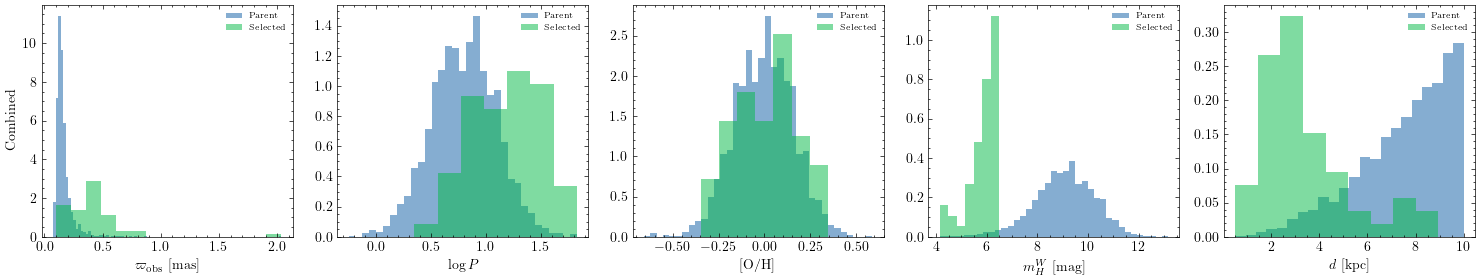

In [35]:
def plot_mock_data(seed=0):
    """Generate one mock and plot the data distributions."""
    combined, per_campaign = generate_mock(seed, which, CONFIGS)
    sel = combined["sel"]
    N_tot = len(sel)
    N_sel = sel.sum()

    print(f"Mock seed={seed}: {N_sel}/{N_tot} selected (combined)")
    for c in which:
        s = per_campaign[c]["sel"]
        print(f"  {c}: {s.sum()}/{len(s)} selected")

    panels = [
        ("varpi_obs", r"$\varpi_{\rm obs}$ [mas]"),
        ("logP", r"$\log P$"),
        ("OH_obs", r"$[\mathrm{O/H}]$"),
        ("m_obs", r"$m^{W}_{H}$ [mag]"),
        ("d_true", r"$d$ [kpc]"),
    ]

    multi = len(which) > 1
    nrows = 1 + len(which) if multi else 1
    ncols = len(panels)

    with plt.style.context("science"):
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(3 * ncols, 3 * nrows), squeeze=False)

        # Combined row
        for j, (key, xlabel) in enumerate(panels):
            ax = axes[0, j]
            v = combined[key]
            ax.hist(v, bins="auto", alpha=0.5, density=True, label="Parent")
            ax.hist(v[sel], bins="auto", alpha=0.5, density=True,
                    label="Selected")
            ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel("Combined")
            ax.legend(fontsize=6)

        # Per-campaign rows
        if multi:
            for i, c in enumerate(which):
                d = per_campaign[c]
                s = d["sel"]
                for j, (key, xlabel) in enumerate(panels):
                    ax = axes[1 + i, j]
                    v = d[key]
                    ax.hist(v, bins="auto", alpha=0.5, density=True,
                            label="Parent")
                    ax.hist(v[s], bins="auto", alpha=0.5, density=True,
                            label="Selected")
                    ax.set_xlabel(xlabel)
                    if j == 0:
                        ax.set_ylabel(c)
                    ax.legend(fontsize=6)

        fig.tight_layout()
        plt.show()


plot_mock_data(1)

## 3. Run mock tests

In [6]:
N_check = 1000
counts = np.array([generate_mock(i, which, CONFIGS)[0]["sel"].sum()
                    for i in range(N_check)])
print(f"Selected samples: {counts.mean():.1f} +/- {counts.std():.1f} "
      f"(over {N_check} realisations)")

Selected samples: 26.1 +/- 4.2 (over 1000 realisations)


In [10]:
import sys
from pathlib import Path

MOCK_RUN_DIR = None
for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = parent / "scripts" / "runs" / "mwcepheids" / "mocks"
    if candidate.exists():
        MOCK_RUN_DIR = candidate
        break
if MOCK_RUN_DIR is None:
    raise FileNotFoundError("Could not find scripts/runs/mwcepheids/mocks")
if str(MOCK_RUN_DIR) not in sys.path:
    sys.path.insert(0, str(MOCK_RUN_DIR))

use_forward = True # Set True for full forward model (MWCepheidModel)

N_mocks = 50
N_workers = 10
print(f"Running {N_mocks} mocks on {N_workers} workers (1 chain each)")
print(f"Model: {'forward' if use_forward else 'simplified chi2'}")

if use_forward:
    import logging
    import tomllib

    from candel.inference import run_MWCepheids_inference
    from candel.model import MWCepheidModel
    from mock_forward_utils import generate_mock_forward

    _FWD_TOML = {"C22": str(MOCK_RUN_DIR / "config_mock_mW.toml"), "C27": str(MOCK_RUN_DIR / "config_mock_pi.toml")}
    _PRI = ["M_H_1", "b_W", "Z_W", "delta_pi", "sigma_int"]
    _POP = ["mu_logP", "sigma_logP", "mu_OH", "sigma_OH"]
    _mw_log = logging.getLogger("candel.model.mwcepheids")

    # Forward → simplified name mapping for downstream cells
    _FWD_REMAP = {"M_H_1": "MWH", "b_W": "bW", "Z_W": "ZW"}

    def _run_fwd(seed, campaign, toml_path, mock_cfg):
        data, _, _ = generate_mock_forward(
            seed, TRUE_PARAMS, mock_cfg, campaign)

        # Suppress MW Cepheid model logging in worker
        prev_level = _mw_log.level
        _mw_log.setLevel(logging.ERROR)

        with open(toml_path, "rb") as f:
            config = tomllib.load(f)
        config["inference"]["seed"] = seed
        config["model"]["n_mc_selection"] = 1
        config["model"][campaign]["d_min"] = mock_cfg["d_min"]
        config["model"][campaign]["d_max"] = mock_cfg["d_max"]
        if campaign == "C22":
            if mock_cfg.get("mW_max") is not None:
                config["model"]["C22"]["selection"]["mW_max"] = mock_cfg["mW_max"]
            if mock_cfg.get("logP_min") is not None:
                config["model"]["C22"]["selection"]["apply_logP"] = True
                config["model"]["C22"]["selection"]["logP_min"] = mock_cfg["logP_min"]
                config["model"]["C22"]["selection"]["logP_width"] = 0.0
        if campaign == "C27" and mock_cfg.get("varpi_cut") is not None:
            config["model"]["C27"]["selection"]["pi_min"] = mock_cfg["varpi_cut"]

        model = MWCepheidModel(config, data)
        _, samples = run_MWCepheids_inference(
            model, print_summary=False, save_samples=False,
            progress_bar=False, return_mcmc=True)
        _mw_log.setLevel(prev_level)

        biases = {}
        for p in _PRI:
            if p in samples:
                s = np.asarray(samples[p])
                biases[p] = (s.mean() - TRUE_PARAMS[p]) / s.std()
        for p in _POP:
            key = f"{p}_{campaign}"
            if key in samples:
                true_val = mock_cfg.get(p, TRUE_PARAMS.get(p))
                s = np.asarray(samples[key])
                biases[key] = (s.mean() - true_val) / s.std()
        return biases

    all_biases = {}
    for camp in which:
        toml_file = _FWD_TOML[camp]
        mock_cfg = CONFIGS[camp]
        label = f"{camp}_{'mW' if mock_cfg.get('mW_max') is not None else 'pi'}"
        print(f"\n--- {camp} (forward model) ---")
        sel_info = f"d=[{mock_cfg['d_min']}, {mock_cfg['d_max']}], "
        sel_info += f"N_parent={mock_cfg['N_parent']}, "
        if camp == "C22":
            sel_info += f"mW_max={mock_cfg.get('mW_max')}"
            if mock_cfg.get("logP_min") is not None:
                sel_info += f", logP_min={mock_cfg['logP_min']:.3f}"
        else:
            sel_info += f"varpi_cut={mock_cfg.get('varpi_cut')}"
        print(f"  {sel_info}")
        res = Parallel(n_jobs=N_workers, return_as="generator")(
            delayed(_run_fwd)(i, camp, toml_file, mock_cfg)
            for i in range(N_mocks))
        res = list(tqdm(res, total=N_mocks, desc=label))

        all_params = _PRI + [f"{p}_{camp}" for p in _POP]
        for p in all_params:
            vals = [b[p] for b in res if p in b]
            if vals:
                all_biases[p] = np.array(vals)

    # Remap forward model names to match simplified model keys
    for old, new in _FWD_REMAP.items():
        if old in all_biases:
            all_biases[new] = all_biases.pop(old)

else:
    if N_mocks == 1:
        results = [run_one_mock(0, which, CONFIGS, verbose=True, num_chains=4)]
    else:
        results = Parallel(n_jobs=N_workers, return_as="generator")(
            delayed(run_one_mock)(i, which, CONFIGS) for i in range(N_mocks)
        )
        results = list(tqdm(results, total=N_mocks))

    all_biases = {lab: [] for lab in TRUE_VALS}
    for biases in results:
        for lab in biases:
            all_biases[lab].append(biases[lab])

    for lab in list(all_biases):
        if all_biases[lab]:
            all_biases[lab] = np.array(all_biases[lab])
        else:
            del all_biases[lab]

print(f"\nDone: {N_mocks} mocks, {len(all_biases)} parameters tracked")

Running 50 mocks on 10 workers (1 chain each)
Model: forward

--- C27 (forward model) ---
  d=[0.3, 2], N_parent=100, varpi_cut=0.8


C27_pi:   0%|          | 0/50 [00:00<?, ?it/s]


Done: 50 mocks, 9 parameters tracked


## 4. Bias distribution

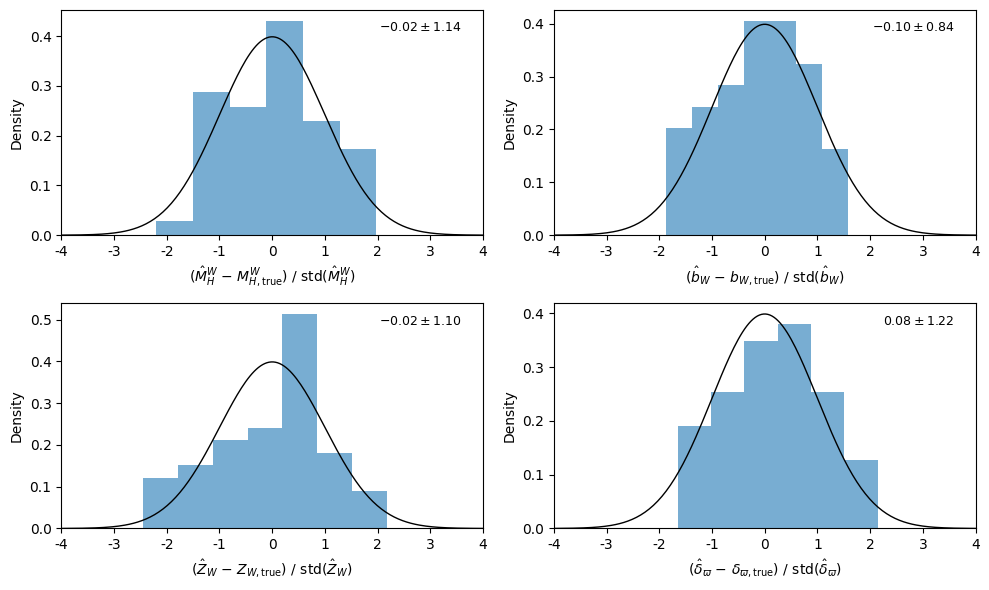

In [11]:
latex_labels = {
    "MWH": (r"$\hat{M}^{W}_{H}$", r"$M^{W}_{H, \mathrm{true}}$", r"$\hat{M}^{W}_{H}$"),
    "bW": (r"$\hat{b}_{W}$", r"$b_{W, \mathrm{true}}$", r"$\hat{b}_{W}$"),
    "ZW": (r"$\hat{Z}_{W}$", r"$Z_{W, \mathrm{true}}$", r"$\hat{Z}_{W}$"),
    "delta_pi": (r"$\hat{\delta}_{\varpi}$", r"$\delta_{\varpi, \mathrm{true}}$", r"$\hat{\delta}_{\varpi}$"),
}

sampled_labs = [lab for lab in ["MWH", "bW", "ZW", "delta_pi"]
                if lab in all_biases]
n = len(sampled_labs)
ncols = min(n, 2)
nrows = (n + ncols - 1) // ncols

# with plt.style.context("science"):
if True:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows),
                             squeeze=False)
    x = np.linspace(-4, 4, 200)

    for ax, lab in zip(axes.flat, sampled_labs):
        b = all_biases[lab]
        hat, true, std = latex_labels[lab]
        ax.hist(b, bins="auto", density=True, alpha=0.6)
        ax.plot(x, norm.pdf(x), "k-", lw=1)
        ax.set_xlabel(f"({hat} $-$ {true}) / std({std})")
        ax.set_ylabel("Density")
        ax.set_xlim(-4, 4)
        ax.text(0.95, 0.95, f"${b.mean():.2f} \\pm {b.std():.2f}$",
                transform=ax.transAxes, ha="right", va="top", fontsize=9)

    # Hide unused axes
    for ax in axes.flat[n:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

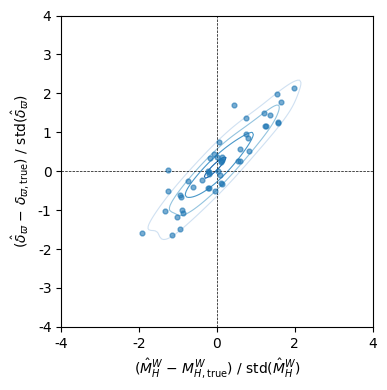

In [12]:
from scipy.stats import gaussian_kde

if "MWH" in all_biases and "delta_pi" in all_biases:
    # with plt.style.context("science"):
    if True:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))

        bM = all_biases["MWH"]
        bdp = all_biases["delta_pi"]

        # KDE contours
        xy = np.vstack([bM, bdp])
        kde = gaussian_kde(xy)
        xg = np.linspace(-4, 4, 150)
        yg = np.linspace(-4, 4, 150)
        Xg, Yg = np.meshgrid(xg, yg)
        Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
        ax.contour(Xg, Yg, Z, levels=4, cmap="Blues", linewidths=0.8)

        ax.scatter(bM, bdp, s=12, alpha=0.6, zorder=5)
        ax.axhline(0, color="k", ls="--", lw=0.5)
        ax.axvline(0, color="k", ls="--", lw=0.5)
        ax.set_xlabel(r"($\hat{M}^{W}_{H}$ $-$ $M^{W}_{H, \mathrm{true}}$) / std($\hat{M}^{W}_{H}$)")
        ax.set_ylabel(r"($\hat{\delta}_{\varpi}$ $-$ $\delta_{\varpi, \mathrm{true}}$) / std($\hat{\delta}_{\varpi}$)")
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")

        fig.tight_layout()
        plt.show()
else:
    print("Skipping 2D plot: MWH and/or delta_pi not sampled.")

## 5. Batch run: all campaigns x likelihood types

In [8]:
def run_batch(campaign_list, use_gaussian, N_mocks=500, N_workers=10):
    """Run N_mocks for given campaigns and likelihood, return bias arrays."""
    w = campaign_list if isinstance(campaign_list, list) else [campaign_list]

    results = Parallel(n_jobs=N_workers, return_as="generator")(
        delayed(run_one_mock)(i, w, CONFIGS, use_gaussian=use_gaussian)
        for i in range(N_mocks)
    )
    lbl = likelihood_label(use_gaussian)
    results = list(tqdm(results, total=N_mocks,
                        desc=f"{'+'.join(w)}, {lbl}"))

    biases = {lab: [] for lab in TRUE_VALS}
    for b in results:
        for lab in b:
            biases[lab].append(b[lab])

    for lab in list(biases):
        if biases[lab]:
            biases[lab] = np.array(biases[lab])
        else:
            del biases[lab]

    return biases


N_mocks_batch = 50
N_workers_batch = 10

BATCH_TASKS = [
    ("C22", True),
    ("C22", False),
    ("C27", True),
    ("C27", "parallax_selection"),
    ("C27", False),
]

batch_results = {}
for camp, use_g in BATCH_TASKS:
    label = f"{camp}_{likelihood_label(use_g)}"
    print(f"\n=== {label} ===")
    batch_results[label] = run_batch(
        camp, use_g, N_mocks=N_mocks_batch, N_workers=N_workers_batch)

print("\nAll batch runs complete.")


=== C22_gaussian ===


C22, gaussian:   0%|          | 0/50 [00:00<?, ?it/s]

/mnt/users/rstiskalek/CANDEL/venv_candel/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== C22_chi2 ===


C22, chi2:   0%|          | 0/50 [00:00<?, ?it/s]

...


=== C27_parallax_selection ===


C27, parallax_selection:   0%|          | 0/50 [00:00<?, ?it/s]


=== C27_chi2 ===


C27, chi2:   0%|          | 0/50 [00:00<?, ?it/s]


All batch runs complete.


In [9]:
params = ["MWH", "bW", "ZW", "delta_pi"]

header = f"{'Run':<28s}" + "".join(f"{p:>18s}" for p in params)
print(header)
print("-" * len(header))
for label, biases in batch_results.items():
    row = f"{label:<28s}"
    for p in params:
        if p in biases:
            b = biases[p]
            entry = f"{b.mean():+.2f} +/- {b.std():.2f}"
            row += f"{entry:>18s}"
        else:
            row += f"{'---':>18s}"
    print(row)

Run                                        MWH                bW                ZW          delta_pi
----------------------------------------------------------------------------------------------------
C22_gaussian                    -1.31 +/- 1.13    -0.16 +/- 0.88    +0.12 +/- 0.91    -0.37 +/- 0.97
C22_chi2                        +1.55 +/- 1.12    +1.99 +/- 0.90    +0.16 +/- 0.78    +2.53 +/- 1.11
C27_gaussian                    -0.69 +/- 0.97    -0.13 +/- 1.07    +0.26 +/- 0.90    -1.23 +/- 0.67
C27_parallax_selection          -0.72 +/- 0.99    -0.16 +/- 1.17    +0.30 +/- 0.99    +0.11 +/- 0.64
C27_chi2                        +0.49 +/- 0.86    -0.16 +/- 1.05    +0.28 +/- 0.87    +0.25 +/- 0.49


In [10]:
outfile = "../../results/mock_chi2_batch.npz"

if 'batch_results' in dir() and batch_results:
    save_dict = {}
    for label, biases in batch_results.items():
        for lab, arr in biases.items():
            save_dict[f"{label}_{lab}"] = arr

    save_dict["labels"] = np.array(list(batch_results.keys()))
    save_dict["params"] = np.array(["MWH", "bW", "ZW", "delta_pi"])
    np.savez(outfile, **save_dict)
    print(f"Saved to {outfile}")
else:
    data = np.load(outfile, allow_pickle=True)
    labels = list(data["labels"])
    params_all = list(data["params"])
    batch_results = {}
    for label in labels:
        batch_results[label] = {}
        for p in params_all:
            key = f"{label}_{p}"
            if key in data:
                batch_results[label][p] = data[key]
    print(f"Loaded from {outfile}")

Saved to ../../results/mock_chi2_batch.npz


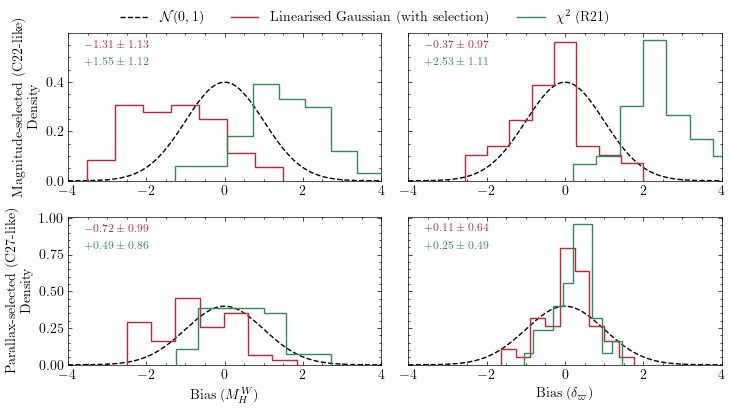

In [11]:
params = ["MWH", "delta_pi"]
param_labels = {
    "MWH": r"$M^W_H$",
    "delta_pi": r"$\delta_\varpi$",
}
campaigns = ["C22", "C27"]
campaign_sel_labels = {
    "C22": "Magnitude-selected (C22-like)",
    "C27": "Parallax-selected (C27-like)",
}

# Colours from config_MWCepheids_paper.toml
colours = ["#c52233", "#0e0004", "#2e8b57", "#3c91e6", "#f2a359"]

campaign_ltypes = {
    "C22": ["gaussian", "chi2"],
    "C27": ["parallax_selection", "chi2"],
}

ltype_colors = {
    "gaussian": colours[0],
    "parallax_selection": colours[0],
    "chi2": colours[2],
}

grouped = {c: {} for c in campaigns}
for label, biases in batch_results.items():
    for c in campaigns:
        if label.startswith(c + "_"):
            ltype = label[len(c) + 1:]
            grouped[c][ltype] = biases

x = np.linspace(-4, 4, 200)

with plt.style.context("science"):
    fig, axes = plt.subplots(2, 2, figsize=(7.5, 4.), squeeze=False,
                             sharey="row")

    for i, camp in enumerate(campaigns):
        for j, p in enumerate(params):
            ax = axes[i, j]
            ax.plot(x, norm.pdf(x), "k--",)

            text_lines = []
            for ltype in campaign_ltypes[camp]:
                if ltype in grouped[camp] and p in grouped[camp][ltype]:
                    b = grouped[camp][ltype][p]
                    ax.hist(b, bins="auto", density=True, histtype="step",
                            color=ltype_colors[ltype])
                    text_lines.append(
                        (f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                         ltype_colors[ltype]))

            for k, (txt, col) in enumerate(text_lines):
                ax.text(0.05, 0.95 - k * 0.12, txt,
                        transform=ax.transAxes, ha="left", va="top",
                        fontsize=8, color=col)

            ax.set_xlim(-4, 4)
            if i == 1:
                ax.set_xlabel(f"Bias ({param_labels[p]})")
            if j == 0:
                ax.set_ylabel(
                    f"{campaign_sel_labels[camp]}\nDensity")

    from matplotlib.lines import Line2D
    handles = [
        Line2D([], [], color="k", ls="--", lw=1, label=r"$\mathcal{N}(0,1)$"),
        Line2D([], [], color=colours[0], lw=1, label="Linearised Gaussian (with selection)"),
        Line2D([], [], color=colours[2], lw=1, label=r"$\chi^2$ (R21)"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               bbox_to_anchor=(0.5, 1.05))

    fig.tight_layout()
    fig.savefig(os.path.expanduser("~/Downloads/mock_bias.pdf"),
                dpi=450, bbox_inches="tight")
    plt.show()

## 6. Full forward model closure tests

Load pre-computed results from `scripts/runs/mwcepheids/mocks/run_mock_forward.py`, or run inline.
These use `MWCepheidModel` directly with volume prior and hard selection cuts.

In [ ]:
import sys
from pathlib import Path

MOCK_RUN_DIR = None
for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = parent / "scripts" / "runs" / "mwcepheids" / "mocks"
    if candidate.exists():
        MOCK_RUN_DIR = candidate
        break
if MOCK_RUN_DIR is None:
    raise FileNotFoundError("Could not find scripts/runs/mwcepheids/mocks")
if str(MOCK_RUN_DIR) not in sys.path:
    sys.path.insert(0, str(MOCK_RUN_DIR))

from candel.inference import run_MWCepheids_inference
from candel.model import MWCepheidModel
import tomllib

from mock_forward_utils import (
    generate_mock_forward, TRUE_PARAMS, MOCK_CFG_MW, MOCK_CFG_PI,
    EPSILON_OH,
)

# Forward model tasks: (campaign, toml_file, mock_cfg, label)
FORWARD_TASKS = [
    ("C22", str(MOCK_RUN_DIR / "config_mock_mW.toml"), MOCK_CFG_MW, "C22_mW"),
    ("C27", str(MOCK_RUN_DIR / "config_mock_pi.toml"), MOCK_CFG_PI, "C27_pi"),
]

PRIMARY_PARAMS = ["M_H_1", "b_W", "Z_W", "delta_pi", "sigma_int"]
POPULATION_PARAMS = ["mu_logP", "sigma_logP", "mu_OH", "sigma_OH"]

print("TRUE_PARAMS:", TRUE_PARAMS)

In [ ]:
# Visualise a single forward model mock
seed = 0
for campaign, toml_file, mock_cfg, label in FORWARD_TASKS:
    data, n_parent, n_sel = generate_mock_forward(seed, TRUE_PARAMS, mock_cfg, campaign)
    print(f"{label}: {n_parent} parent -> {n_sel} selected")
    print(f"  mW range: [{float(data.mW_H.min()):.2f}, {float(data.mW_H.max()):.2f}]")
    print(f"  pi range: [{float(data.pi_EDR3.min()):.3f}, {float(data.pi_EDR3.max()):.3f}]")

In [ ]:
# Run or load forward model mocks

def run_one_forward_mock(seed, campaign, toml_path, mock_cfg):
    """Run one forward model mock, return biases dict."""
    import logging
    data, n_parent, n_sel = generate_mock_forward(
        seed, TRUE_PARAMS, mock_cfg, campaign)

    # Suppress MW Cepheid model logging in worker
    mw_log = logging.getLogger("candel.model.mwcepheids")
    prev_level = mw_log.level
    mw_log.setLevel(logging.ERROR)

    with open(toml_path, "rb") as f:
        config = tomllib.load(f)
    config["inference"]["seed"] = seed

    model = MWCepheidModel(config, data)
    mcmc, samples = run_MWCepheids_inference(
        model, print_summary=False, save_samples=False,
        progress_bar=False, return_mcmc=True)
    mw_log.setLevel(prev_level)

    biases = {}
    for param in PRIMARY_PARAMS:
        if param in samples:
            samp = np.asarray(samples[param])
            biases[param] = (samp.mean() - TRUE_PARAMS[param]) / samp.std()

    for param in POPULATION_PARAMS:
        key = f"{param}_{campaign}"
        if key in samples:
            true_val = mock_cfg.get(param, TRUE_PARAMS.get(param))
            samp = np.asarray(samples[key])
            biases[key] = (samp.mean() - true_val) / samp.std()

    return biases


N_forward_mocks = 50
N_forward_workers = 4
forward_outfile = "../../results/mocks/mock_forward_batch.npz"
run_forward = False  # Set True to run, False to load from file

In [ ]:
if run_forward:
    forward_results = {}
    for campaign, toml_file, mock_cfg, label in FORWARD_TASKS:
        print(f"\n--- {label} (forward model) ---")
        res = Parallel(n_jobs=N_forward_workers, return_as="generator")(
            delayed(run_one_forward_mock)(i, campaign, toml_file, mock_cfg)
            for i in range(N_forward_mocks))
        res = list(tqdm(res, total=N_forward_mocks, desc=label))

        biases = {}
        all_p = PRIMARY_PARAMS + [f"{pp}_{campaign}" for pp in POPULATION_PARAMS]
        for p in all_p:
            vals = [b[p] for b in res if p in b]
            if vals:
                biases[p] = np.array(vals)
        forward_results[label] = biases

    # Save
    save_dict = {}
    for label, biases in forward_results.items():
        for p, arr in biases.items():
            save_dict[f"{label}/{p}"] = arr
    save_dict["labels"] = np.array(list(forward_results.keys()))
    np.savez(forward_outfile, **save_dict)
    print(f"Saved to {forward_outfile}")
else:
    data = np.load(forward_outfile, allow_pickle=True)
    labels = list(data["labels"])
    forward_results = {}
    for label in labels:
        forward_results[label] = {
            k.split("/")[1]: data[k]
            for k in data if k.startswith(label + "/")}
    print(f"Loaded from {forward_outfile}: {labels}")

In [ ]:
# Summary table
print("Forward model: mean standardised bias +/- std")
print("=" * 80)
for label, biases in forward_results.items():
    print(f"\n{label}:")
    for p in sorted(biases.keys()):
        b = biases[p]
        print(f"  {p:>20s}: {b.mean():+.2f} +/- {b.std():.2f}  (N={len(b)})")

In [ ]:
# Bias histograms: primary P-L parameters

forward_latex = {
    "M_H_1": r"$M^W_{H,1}$",
    "b_W": r"$b_W$",
    "Z_W": r"$Z_W$",
    "delta_pi": r"$\delta_\varpi$",
    "sigma_int": r"$\sigma_{\rm int}$",
}

forward_colors = {"C22_mW": "#c52233", "C27_pi": "#3c91e6"}
x = np.linspace(-4, 4, 200)

with plt.style.context("science"):
    fig, axes = plt.subplots(1, len(PRIMARY_PARAMS),
                             figsize=(3 * len(PRIMARY_PARAMS), 3))

    for j, p in enumerate(PRIMARY_PARAMS):
        ax = axes[j]
        ax.plot(x, norm.pdf(x), "k--", lw=1)

        for label, biases in forward_results.items():
            if p in biases:
                b = biases[p]
                ax.hist(b, bins="auto", density=True, histtype="step",
                        color=forward_colors[label], label=label)
                ax.text(0.05, 0.95 - 0.12 * list(forward_results).index(label),
                        f"{label}: ${b.mean():+.2f} \\pm {b.std():.2f}$",
                        transform=ax.transAxes, ha="left", va="top",
                        fontsize=7, color=forward_colors[label])

        ax.set_xlabel(f"Bias ({forward_latex.get(p, p)})")
        ax.set_xlim(-4, 4)
        if j == 0:
            ax.set_ylabel("Density")

    fig.suptitle("Forward model: primary parameters", y=1.02)
    fig.tight_layout()
    plt.show()

In [ ]:
# Bias histograms: population hyperparameters (per campaign)

pop_latex = {
    "mu_logP": r"$\mu_{\log P}$",
    "sigma_logP": r"$\sigma_{\log P}$",
    "mu_OH": r"$\mu_{\rm [O/H]}$",
    "sigma_OH": r"$\sigma_{\rm [O/H]}$",
}

with plt.style.context("science"):
    fig, axes = plt.subplots(len(forward_results), len(POPULATION_PARAMS),
                             figsize=(3 * len(POPULATION_PARAMS),
                                      3 * len(forward_results)),
                             squeeze=False)

    for i, (label, biases) in enumerate(forward_results.items()):
        campaign = label.split("_")[0]
        for j, p in enumerate(POPULATION_PARAMS):
            ax = axes[i, j]
            ax.plot(x, norm.pdf(x), "k--", lw=1)

            key = f"{p}_{campaign}"
            if key in biases:
                b = biases[key]
                ax.hist(b, bins="auto", density=True, alpha=0.6,
                        color=forward_colors[label])
                ax.text(0.05, 0.95,
                        f"${b.mean():+.2f} \\pm {b.std():.2f}$",
                        transform=ax.transAxes, ha="left", va="top",
                        fontsize=8, color=forward_colors[label])

            ax.set_xlim(-4, 4)
            if i == len(forward_results) - 1:
                ax.set_xlabel(f"Bias ({pop_latex.get(p, p)})")
            if j == 0:
                ax.set_ylabel(f"{label}\nDensity")

    fig.suptitle("Forward model: population hyperparameters", y=1.02)
    fig.tight_layout()
    plt.show()

In [ ]:
# KS test against N(0,1) for all parameters
from scipy.stats import kstest

print("KS test vs N(0,1):")
print(f"{'Label':<12s} {'Parameter':<22s} {'KS stat':>8s} {'p-value':>8s}")
print("-" * 54)
for label, biases in forward_results.items():
    for p in sorted(biases.keys()):
        b = biases[p]
        stat, pval = kstest(b, "norm")
        flag = " *" if pval < 0.05 else ""
        print(f"{label:<12s} {p:<22s} {stat:8.3f} {pval:8.3f}{flag}")